In [1]:
pip install liac-arff

  Preparing metadata (setup.py) ... done
  Created wheel for liac-arff: filename=liac_arff-2.5.0-py3-none-any.whl size=11716 sha256=97f102f37e86bee411160935927bcbb7ca209f3dfe51a10ec70466a4b9e97d84
  Stored in directory: /root/.cache/pip/wheels/00/23/31/5e562fce1f95aabe57f2a7320d07433ba1cd152bcde2f6a002
Successfully built liac-arff
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import arff
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use('ggplot')

from datetime import datetime, timedelta
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

np.random.seed(42)

import warnings
warnings.filterwarnings("ignore")

# 1. Data Loading and Inspection

In [3]:
X = pd.read_csv("/kaggle/input/production-quality/data_X.csv")
Y = pd.read_csv("/kaggle/input/production-quality/data_Y.csv")
submission = pd.read_csv("/kaggle/input/production-quality/sample_submission.csv")

In [4]:
print("Data_X shape:", X.shape)
print("Data_Y shape:", Y.shape)
print("Sample Submission shape:", submission.shape)

Data_X shape: (2103841, 18)
Data_Y shape: (29184, 2)
Sample Submission shape: (5808, 2)


In [5]:
print("Data_X columns:\n", X.columns)
print("Data_Y columns:\n", Y.columns)
print("Sample Submission columns:\n", submission.columns)

Data_X columns:
 Index(['date_time', 'T_data_1_1', 'T_data_1_2', 'T_data_1_3', 'T_data_2_1', 'T_data_2_2', 'T_data_2_3', 'T_data_3_1', 'T_data_3_2', 'T_data_3_3', 'T_data_4_1', 'T_data_4_2', 'T_data_4_3', 'T_data_5_1', 'T_data_5_2', 'T_data_5_3', 'H_data', 'AH_data'], dtype='object')
Data_Y columns:
 Index(['date_time', 'quality'], dtype='object')
Sample Submission columns:
 Index(['date_time', 'quality'], dtype='object')


In [6]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2103841 entries, 0 to 2103840
Data columns (total 18 columns):
 #   Column      Dtype  
---  ------      -----  
 0   date_time   object 
 1   T_data_1_1  int64  
 2   T_data_1_2  int64  
 3   T_data_1_3  int64  
 4   T_data_2_1  int64  
 5   T_data_2_2  int64  
 6   T_data_2_3  int64  
 7   T_data_3_1  int64  
 8   T_data_3_2  int64  
 9   T_data_3_3  int64  
 10  T_data_4_1  int64  
 11  T_data_4_2  int64  
 12  T_data_4_3  int64  
 13  T_data_5_1  int64  
 14  T_data_5_2  int64  
 15  T_data_5_3  int64  
 16  H_data      float64
 17  AH_data     float64
dtypes: float64(2), int64(15), object(1)
memory usage: 288.9+ MB


In [7]:
Y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29184 entries, 0 to 29183
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   date_time  29184 non-null  object
 1   quality    29184 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 456.1+ KB


In [8]:
submission.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5808 entries, 0 to 5807
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   date_time  5808 non-null   object
 1   quality    5808 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 90.9+ KB


In [9]:
X.head()

,date_time,T_data_1_1,T_data_1_2,T_data_1_3,T_data_2_1,T_data_2_2,T_data_2_3,T_data_3_1,T_data_3_2,T_data_3_3,T_data_4_1,T_data_4_2,T_data_4_3,T_data_5_1,T_data_5_2,T_data_5_3,H_data,AH_data
0,2015-01-01 00:00:00,212,210,211,347,353,347,474,473,481,346,348,355,241,241,243,167.85,9.22
1,2015-01-01 00:01:00,212,211,211,346,352,346,475,473,481,349,348,355,241,241,243,162.51,9.22
2,2015-01-01 00:02:00,212,211,211,345,352,346,476,473,481,352,349,355,242,241,242,164.99,9.22
3,2015-01-01 00:03:00,213,211,211,344,351,346,477,473,481,355,349,355,242,241,242,167.34,9.22
4,2015-01-01 00:04:00,213,211,211,343,350,346,478,473,482,358,349,355,243,241,242,163.04,9.22


In [10]:
Y.head()

,date_time,quality
0,2015-01-04 00:05:00,392
1,2015-01-04 01:05:00,384
2,2015-01-04 02:05:00,393
3,2015-01-04 03:05:00,399
4,2015-01-04 04:05:00,400


In [11]:
submission.head()

,date_time,quality
0,2018-05-04 00:05:00,420
1,2018-05-04 01:05:00,420
2,2018-05-04 02:05:00,420
3,2018-05-04 03:05:00,420
4,2018-05-04 04:05:00,420


In [12]:
missing_counts = X.isna().sum().to_frame(name='missing_counts')
print(missing_counts)

            missing_counts
date_time                0
T_data_1_1               0
T_data_1_2               0
T_data_1_3               0
T_data_2_1               0
T_data_2_2               0
T_data_2_3               0
T_data_3_1               0
T_data_3_2               0
T_data_3_3               0
T_data_4_1               0
T_data_4_2               0
T_data_4_3               0
T_data_5_1               0
T_data_5_2               0
T_data_5_3               0
H_data                   0
AH_data                  0


In [13]:
missing_counts = Y.isna().sum().to_frame(name='missing_counts')
print(missing_counts)

           missing_counts
date_time               0
quality                 0


In [14]:
missing_counts = submission.isna().sum().to_frame(name='missing_counts')
print(missing_counts)

           missing_counts
date_time               0
quality                 0


# 2. Data Cleaning

In [15]:
X_clean = X.copy()
Y_clean = Y.copy()
submission_clean = submission.copy()

In [16]:
numerical_cols = X_clean.select_dtypes(include=['int64', 'float64']).columns

In [ ]:
plt.figure(figsize=(15, len(numerical_cols) * 4))

for i, col in enumerate(numerical_cols):
    plt.subplot(len(numerical_cols), 3, i*3 + 1)
    sns.histplot(X_clean[col], kde=True, color="dodgerblue")
    plt.title(f'Distribution of {col}')
    
    plt.subplot(len(numerical_cols), 3, i*3 + 2)
    sns.boxplot(x=X_clean[col], color="dodgerblue")
    plt.title(f'Boxplot of {col}')
    
    plt.subplot(len(numerical_cols), 3, i*3 + 3)
    res = stats.probplot(X_clean[col].dropna(), plot=plt)
    plt.plot(res[0][0], res[0][1], 'o', color="dodgerblue")
    plt.title(f'Q-Q Plot of {col}')

plt.tight_layout()
plt.show()

In [18]:
def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()
    print(f"Found {outliers} outliers in {column} ({outliers/len(df)*100:.2f}%)")
    
    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
    
    return df

for col in numerical_cols:
    if X_clean[col].nunique() > 10:
        X_clean = cap_outliers(X_clean, col)

Found 22541 outliers in T_data_1_1 (1.07%)
Found 18670 outliers in T_data_1_2 (0.89%)
Found 17938 outliers in T_data_1_3 (0.85%)
Found 44772 outliers in T_data_2_1 (2.13%)
Found 42387 outliers in T_data_2_2 (2.01%)
Found 42548 outliers in T_data_2_3 (2.02%)
Found 31714 outliers in T_data_3_1 (1.51%)
Found 30326 outliers in T_data_3_2 (1.44%)
Found 33924 outliers in T_data_3_3 (1.61%)
Found 41911 outliers in T_data_4_1 (1.99%)
Found 40083 outliers in T_data_4_2 (1.91%)
Found 44318 outliers in T_data_4_3 (2.11%)
Found 20042 outliers in T_data_5_1 (0.95%)
Found 18097 outliers in T_data_5_2 (0.86%)
Found 21729 outliers in T_data_5_3 (1.03%)
Found 0 outliers in H_data (0.00%)
Found 14460 outliers in AH_data (0.69%)


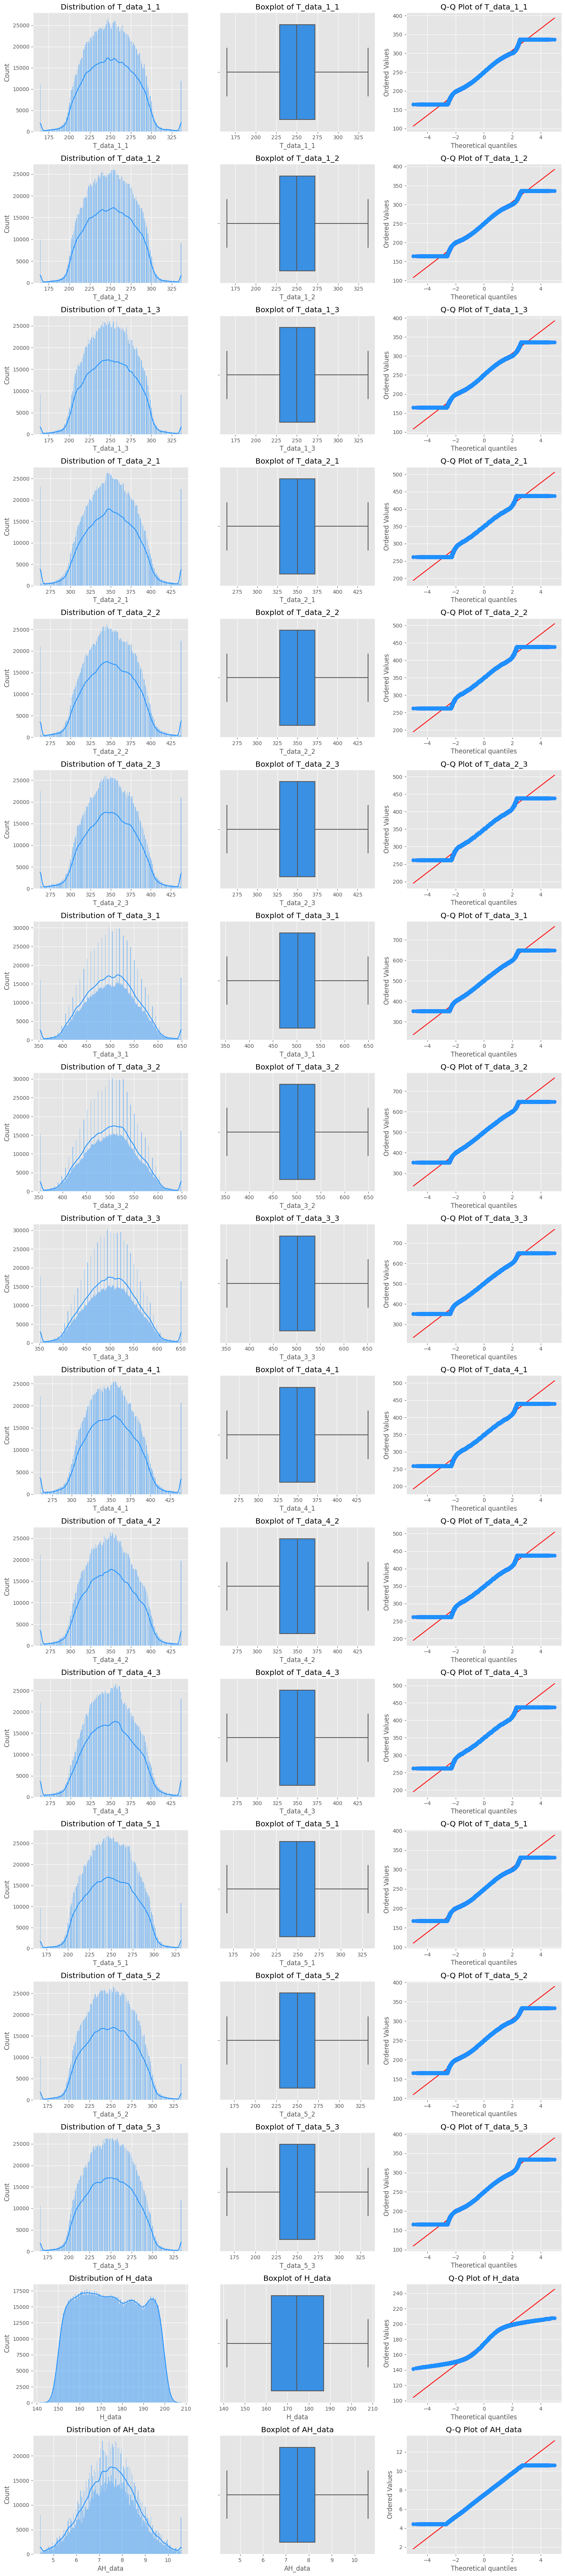

In [19]:
plt.figure(figsize=(15, len(numerical_cols) * 4))

for i, col in enumerate(numerical_cols):
    plt.subplot(len(numerical_cols), 3, i*3 + 1)
    sns.histplot(X_clean[col], kde=True, color="dodgerblue")
    plt.title(f'Distribution of {col}')
    
    plt.subplot(len(numerical_cols), 3, i*3 + 2)
    sns.boxplot(x=X_clean[col], color="dodgerblue")
    plt.title(f'Boxplot of {col}')
    
    plt.subplot(len(numerical_cols), 3, i*3 + 3)
    res = stats.probplot(X_clean[col].dropna(), plot=plt)
    plt.plot(res[0][0], res[0][1], 'o', color="dodgerblue")
    plt.title(f'Q-Q Plot of {col}')

plt.tight_layout()
plt.show()

In [20]:
X_clean['date_time'] = pd.to_datetime(X_clean['date_time'])
Y_clean['date_time'] = pd.to_datetime(Y_clean['date_time'])
submission_clean['date_time'] = pd.to_datetime(submission_clean['date_time'])

In [21]:
X_clean["date_hour"] = X_clean["date_time"].apply(lambda x: x.strftime("%Y-%m-%d-%H"))
Y_clean["date_hour"] = Y_clean["date_time"].apply(lambda x: x.strftime("%Y-%m-%d-%H"))
submission_clean["date_hour"] = submission_clean["date_time"].apply(lambda x: x.strftime("%Y-%m-%d-%H"))

In [22]:
print(f"X_clean date range: {X_clean['date_time'].min()} to {X_clean['date_time'].max()}")
print(f"Y_clean date range: {Y_clean['date_time'].min()} to {Y_clean['date_time'].max()}")
print(f"submission_clean date range: {submission_clean['date_time'].min()} to {submission_clean['date_time'].max()}")

X_clean date range: 2015-01-01 00:00:00 to 2019-01-01 00:00:00
Y_clean date range: 2015-01-04 00:05:00 to 2018-05-03 23:05:00
submission_clean date range: 2018-05-04 00:05:00 to 2018-12-31 23:05:00


In [23]:
X_hourly = X_clean.groupby('date_hour').agg({
    col: 'mean' for col in numerical_cols
}).reset_index()

X_hourly = X_hourly.rename(columns={'date_hour': 'date_time'})

In [24]:
print(f"X_hourly shape: {X_hourly.shape}")

X_hourly shape: (35065, 18)


# **3. Exploratory Data Analysis (EDA)**

In [25]:
numerical_cols = X_hourly.select_dtypes(include=['int64', 'float64']).columns

In [26]:
numerical_summary = X_hourly[numerical_cols].describe()[1:].T
numerical_summary['range'] = numerical_summary['max'] - numerical_summary['min']
numerical_summary['coefficient_of_variation'] = numerical_summary['std'] / numerical_summary['mean'] * 100
numerical_summary = numerical_summary.style.background_gradient(cmap='coolwarm')
display(numerical_summary)

,mean,std,min,25%,50%,75%,max,range,coefficient_of_variation
T_data_1_1,250.171737,28.419582,164.500000,228.766667,250.133333,271.533333,336.500000,172.000000,11.360029
T_data_1_2,250.150735,28.201326,164.500000,228.750000,250.216667,271.516667,336.500000,172.000000,11.273733
T_data_1_3,250.294294,28.155648,164.500000,228.983333,250.216667,271.533333,336.500000,172.000000,11.249017
T_data_2_1,349.904507,30.460501,262.000000,328.266667,349.950000,371.750000,438.000000,176.000000,8.705375
T_data_2_2,349.818903,30.297439,262.000000,328.000000,349.466667,371.900000,438.000000,176.000000,8.660892
T_data_2_3,349.813135,30.222597,262.000000,328.266667,349.716667,371.583333,438.000000,176.000000,8.639640
T_data_3_1,501.043212,52.052084,353.000000,463.816667,501.633333,537.850000,649.000000,296.000000,10.388742
T_data_3_2,501.009741,51.815779,353.000000,463.950000,501.616667,537.266667,649.000000,296.000000,10.342270
T_data_3_3,501.405713,52.366787,351.500000,464.566667,501.816667,538.350000,651.500000,300.000000,10.443995
T_data_4_1,349.406174,30.650926,259.500000,327.333333,349.333333,371.183333,439.500000,180.000000,8.772291


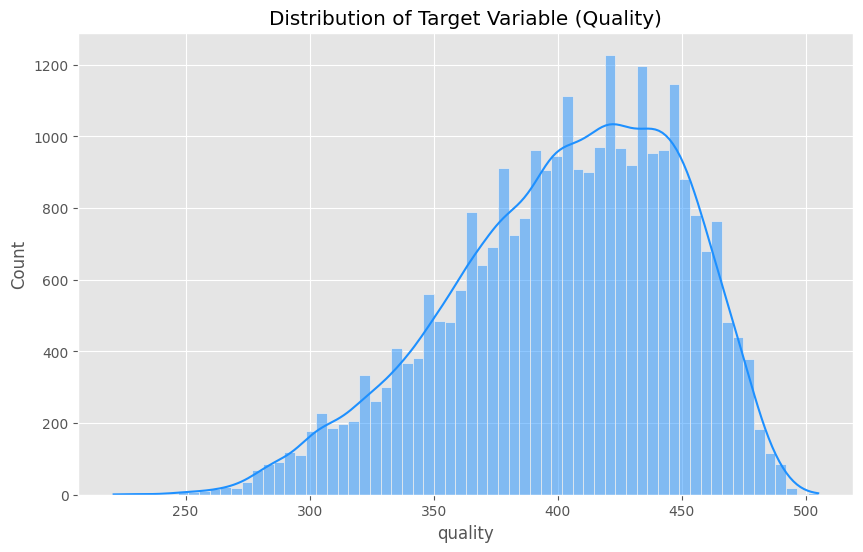

Summary statistics of target variable:


count    29184.000000
mean       402.800747
std         46.273228
min        221.000000
25%        372.000000
50%        408.000000
75%        439.000000
max        505.000000
Name: quality, dtype: float64

In [27]:
if 'quality' in Y_clean.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(Y_clean['quality'], kde=True, color='dodgerblue')
    plt.title('Distribution of Target Variable (Quality)')
    plt.show()
    
    print("Summary statistics of target variable:")
    display(Y_clean['quality'].describe())

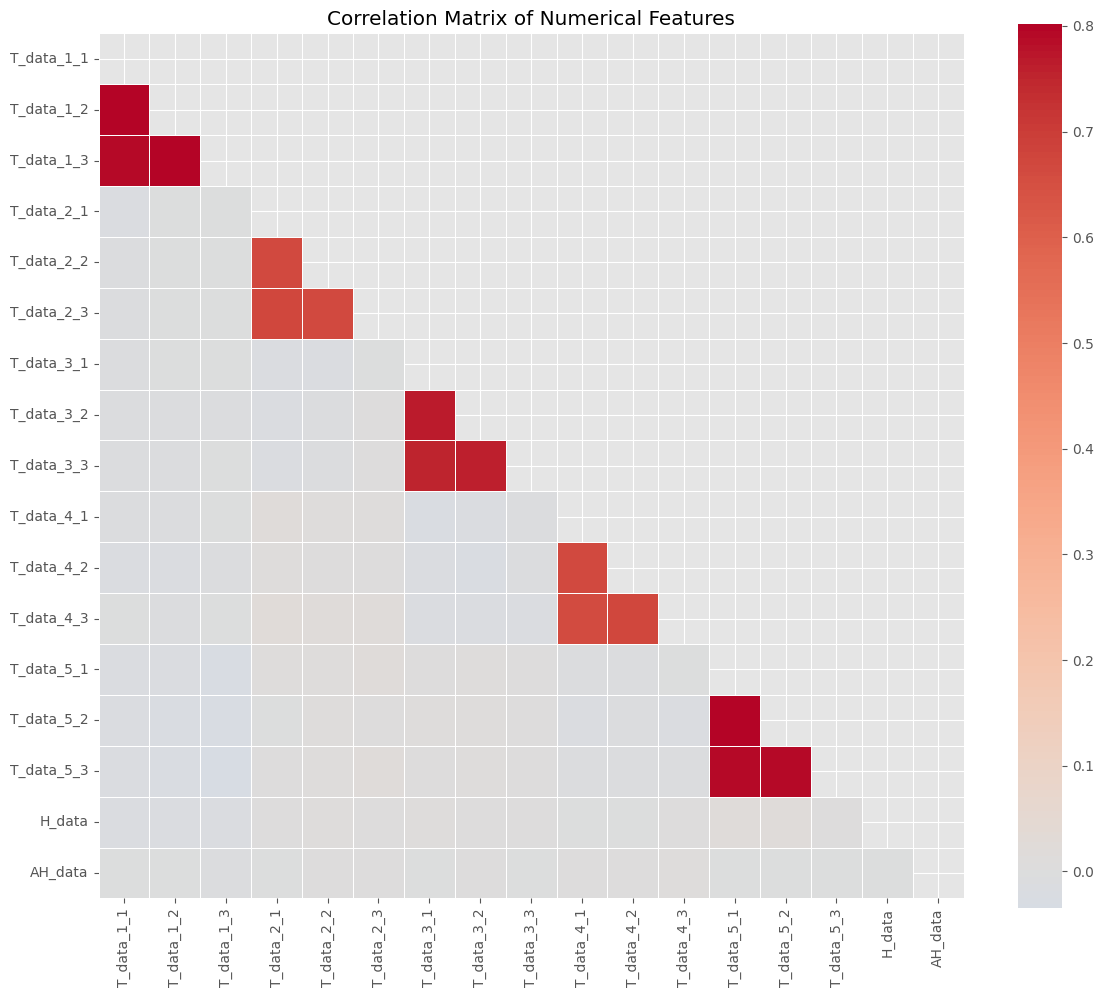

Highly correlated features (|corr| > 0.7):
{'T_data_3_2', 'T_data_5_2', 'T_data_3_3', 'T_data_1_2', 'T_data_5_3', 'T_data_1_3'}


In [28]:
# Correlation analysis
correlation_matrix = X_hourly[numerical_cols].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=False, cmap='coolwarm', 
            center=0, square=True, linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

# Identify highly correlated features
threshold = 0.7
high_corr_features = set()

for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            featurename = correlation_matrix.columns[i]
            high_corr_features.add(featurename)
            
print(f"Highly correlated features (|corr| > {threshold}):")
print(high_corr_features)

# **4. Feature Engineering**

In [29]:
X_engineered = X_hourly.copy()
X_engineered['date_time'] = pd.to_datetime(X_engineered['date_time'])

In [30]:
X_engineered['hour'] = X_engineered['date_time'].dt.hour
X_engineered['dayofweek'] = X_engineered['date_time'].dt.dayofweek

In [31]:
X_engineered['hour_sin'] = np.sin(2 * np.pi * X_engineered['hour']/24)
X_engineered['hour_cos'] = np.cos(2 * np.pi * X_engineered['hour']/24)

In [32]:
X_engineered['dayofweek_sin'] = np.sin(2 * np.pi * X_engineered['dayofweek']/7)
X_engineered['dayofweek_cos'] = np.cos(2 * np.pi * X_engineered['dayofweek']/7)

In [33]:
X_engineered.drop(columns=["hour", "dayofweek"], inplace=True)

In [34]:
print(f"Feature engineered data shape: {X_engineered.shape}")

Feature engineered data shape: (35065, 22)


# **5. Train-Test Split**

In [35]:
print("X_hourly shape:", X_engineered.shape)
print("Y_hourly shape:", Y_clean.shape)
print("submission_hourly shape:", submission_clean.shape)

X_hourly shape: (35065, 22)
Y_hourly shape: (29184, 3)
submission_hourly shape: (5808, 3)


In [36]:
X_engineered["date_hour"] = X_engineered["date_time"].apply(lambda x: x.strftime("%Y-%m-%d-%H"))

In [37]:
training_data = pd.merge(
    X_engineered,
    Y_clean[["date_hour", "quality"]],
    left_on="date_hour",
    right_on="date_hour",
    how="inner"
)

In [38]:
sampling_data = pd.merge(
    X_engineered,
    submission_clean[["date_hour", "quality"]],
    left_on="date_hour",
    right_on="date_hour",
    how="inner"
)

In [39]:
training_data = training_data.drop(["date_hour"], axis=1)
sampling_data = sampling_data.drop(["date_hour"], axis=1)

In [40]:
print(f"Training data shape after merging: {training_data.shape}")
print(f"Sampling data shape after merging: {sampling_data.shape}")

Training data shape after merging: (29184, 23)
Sampling data shape after merging: (5808, 23)


In [41]:
X_data = training_data.drop(["quality", "date_time"], axis=1)
y_data = training_data["quality"]

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=0)

# 6. Standardization

In [44]:
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

In [45]:
scaler = StandardScaler()

In [46]:
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

In [47]:
X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [48]:
print("Summary statistics after scaling (training set):")
display(X_train_scaled[numerical_cols].describe()[1:].T.style.background_gradient(cmap='coolwarm'))

Summary statistics after scaling (training set):


,mean,std,min,25%,50%,75%,max
T_data_1_1,-0.000000,1.000021,-3.016534,-0.755049,-0.004741,0.755540,3.037557
T_data_1_2,0.000000,1.000021,-3.037564,-0.756261,0.001608,0.755924,3.072752
T_data_1_3,-0.000000,1.000021,-3.052873,-0.752183,-0.003273,0.759572,3.066488
T_data_2_1,-0.000000,1.000021,-2.882134,-0.708323,0.003364,0.717780,2.881222
T_data_2_2,0.000000,1.000021,-2.906519,-0.718583,-0.011516,0.732504,2.917682
T_data_2_3,0.000000,1.000021,-2.921974,-0.710558,-0.001445,0.722050,2.919084
T_data_3_1,0.000000,1.000021,-2.824979,-0.717430,0.016073,0.700867,2.829109
T_data_3_2,0.000000,1.000021,-2.834022,-0.720039,0.022590,0.699788,2.848486
T_data_3_3,0.000000,1.000021,-2.843586,-0.709497,0.016654,0.710007,2.860416
T_data_4_1,0.000000,1.000021,-2.913137,-0.716567,-0.006263,0.712180,2.947277


# **7. Save Processed Data**

In [49]:
output_dir = '/kaggle/working/preprocessed'
os.makedirs(output_dir, exist_ok=True)

In [50]:
train_data = X_train_scaled.copy()
train_data['quality'] = y_train.values

In [51]:
test_data = X_test_scaled.copy()
test_data['quality'] = y_test.values

In [52]:
def dataframe_to_arff(df, relation_name):
    df = df.copy()
    
    if 'date_time' in df.columns:
        df = df.drop('date_time', axis=1)
    
    attributes = []
    for col in df.columns:
        attributes.append((col, 'NUMERIC'))
    
    data = df.values.tolist()
    
    arff_dict = {
        'relation': relation_name,
        'attributes': attributes,
        'data': data
    }
    
    return arff_dict

In [53]:
train_arff = dataframe_to_arff(train_data, 'quality_prediction_train')
with open(f'{output_dir}/train_data.arff', 'w') as f:
    f.write(arff.dumps(train_arff))

In [54]:
test_arff = dataframe_to_arff(test_data, 'quality_prediction_test')
with open(f'{output_dir}/test_data.arff', 'w') as f:
    f.write(arff.dumps(test_arff))

In [56]:
sample_arff = dataframe_to_arff(sampling_data, 'quality_prediction_sample')
with open(f'{output_dir}/sample_data.arff', 'w') as f:
    f.write(arff.dumps(sample_arff))